# The bias variance tradeoff in linear regression

We are going to see how the bias variance tradeoff works in linear regression

In [1]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import the numpy and pandas package
import numpy as np

# Import matplotlib libraries to visualize the data
import matplotlib.pyplot as plt 

# Import library to fit linear regression
import statsmodels.api as sm



We start by simulating a dataset assuming the linear regression model is true. We start with n=200, p=4, so a classical dataset where you have some data, and the covariates are not that large

Let's start with one simulation. Notice that from now on I will set the random seed to allow replicability



In [80]:
np.random.seed(seed=1)

n=200
p=4
eps=np.random.randn(n)
beta=np.arange(p+1)

X=np.random.rand(n,p+1)
Y=X@beta+eps

# Fitting the resgression line using 'OLS'
lr = sm.OLS(Y, X).fit()

# We can compute the bias as 
bias=lr.params-beta
print(bias)


[-0.35166297 -0.23562003  0.04118475  0.47313585  0.23859286]


# Multiple simulations

We can't compute the variance with a single simulation though. So we will repeat the previous task many times, and then compute bias and variance, and compare their relative magnitude

In [100]:
np.random.seed(seed=1)

nsim=100
n=200
p=4
beta=np.arange(p+1)
X=np.random.rand(n,p+1)
par_matrix=np.empty((nsim,p+1))

for j in range(nsim):
    eps=np.random.randn(n)
    Y=X@beta+eps
    lr = sm.OLS(Y, X).fit()
    par_matrix[j,]=lr.params

# computing squared bias
bias=np.mean(bias_matrix,axis=0)-beta
beta_bias2=np.square(bias)

# computing variance
beta_var=np.var(par_matrix,axis=0)

# let's have a look at the bias2 and variance, for the first element of beta...
print([beta_bias2[1],beta_var[1]])
# ... and on average across beta
print([np.mean(beta_bias2),np.mean(beta_var)])

[0.00042995351009631703, 0.042455934285888]
[0.00017396875862087381, 0.04441314554560359]


# Multiple simulations, large p

Let's try the same experiment by increasing $p$, what do you notice? To simplify the code, I have created a function that performs the simulation

In [101]:
np.random.seed(seed=1)

def biasvar(n,p,nsim):
    beta=np.arange(p+1)
    X=np.random.rand(n,p+1)
    par_matrix=np.empty((nsim,p+1))

    for j in range(nsim):
        eps=np.random.randn(n)
        Y=X@beta+eps
        lr = sm.OLS(Y, X).fit()
        par_matrix[j,]=lr.params

    # computing squared bias
    bias=np.mean(par_matrix,axis=0)-beta
    beta_bias2=np.square(bias)

    # computing variance
    beta_var=np.var(par_matrix,axis=0)    
    return beta_bias2,beta_var


nsim=100
n=200
p=180

beta_bias2,beta_var=biasvar(n,p,nsim)

print([np.mean(beta_bias2),np.mean(beta_var)])


[0.005545948169531953, 0.609471260845374]


# Ridge regression and the bias-variance tradeoff

Clearly with a large $p$ the variance increases by a lot. Using ridge regression, we can tradeoff some (small) bias in exchange for a drastic decrease in variance

Text(0, 0.5, 'MSE/Bias/Variance')

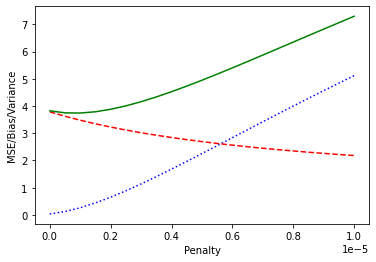

In [156]:
np.random.seed(seed=1)

alpha_range=np.arange(0,1e-5,5e-7)
n_alpha=len(alpha_range)

def biasvar_reg(n,p,nsim):
    beta=np.arange(p+1)
    X=np.random.rand(n,p+1)
    bias_matrix=np.empty((nsim,n_alpha,p+1))

    for j in range(nsim):
        eps=np.random.randn(n)
        Y=X@beta+eps
        rr = sm.OLS(Y, X)
        i=0
        for alpha_count in alpha_range:
            result = rr.fit_regularized(alpha=alpha_count, L1_wt=0)
            bias_matrix[j,i,]=result.params-beta
            i=i+1

    # computing squared bias
    bias=np.mean(bias_matrix,axis=0)
    beta_bias2=np.square(bias)

    # computing variance
    beta_var=np.var(bias_matrix,axis=0)    
    return beta_bias2,beta_var


nsim=100
n=200
p=195

beta_bias2,beta_var=biasvar_reg(n,p,nsim)

# average across all parameters
beta_bias2=np.mean(beta_bias2,axis=1)
beta_var=np.mean(beta_var,axis=1)

plt.plot(alpha_range,beta_bias2,color='b', linestyle='dotted')
plt.plot(alpha_range,beta_var,color = 'r', linestyle='dashed')
plt.plot(alpha_range,beta_bias2+beta_var,color = 'g', linestyle='solid')
plt.xlabel('Penalty')
plt.ylabel('MSE/Bias/Variance')



# Diagnostics

Now let's see how well our model performs on the data.



Text(0, 0.5, 'Parts')

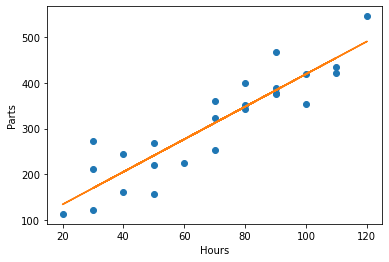

In [18]:

plt.plot(toluca.hours,toluca.parts,'o')
plt.plot(toluca.hours,fitted_values)

plt.xlabel('Hours')
plt.ylabel('Parts')




Let's have a look at the residuals



Text(0, 0.5, 'Parts')

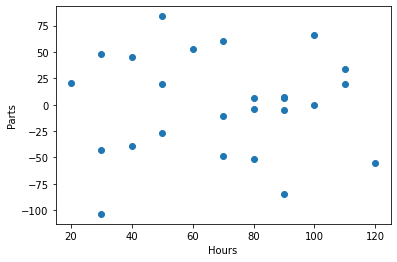

In [19]:
res=fitted_values-toluca.parts

plt.plot(toluca.hours,res,'o')

plt.xlabel('Hours')
plt.ylabel('Parts')


# (Multiple) linear regression

The proposed code works great for simple linear regression, but for multiple linear regression there are other ways

In [30]:
# loading the dataset, careful about the path
dwaine = pd.read_csv("dwaine.csv")
dwaine

x = dwaine[['targtpop','dispoinc']]
x = sm.add_constant(x)

model = sm.OLS(dwaine.sales, x).fit()
predictions = model.predict(x) 
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     99.10
Date:                Thu, 05 Jan 2023   Prob (F-statistic):           1.92e-10
Time:                        10:28:58   Log-Likelihood:                -78.549
No. Observations:                  21   AIC:                             163.1
Df Residuals:                      18   BIC:                             166.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -68.8571     60.017     -1.147      0.2